## Question 1: Moving Average

In [10]:
import pandas as pd 

# The direct raw link to the Johnson & Johnson data on GitHub
url = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/datasets/JohnsonJohnson.csv"

# Pull it straight into a pandas DataFrame
jj_data = pd.read_csv(url, index_col=0)
jj_data.columns = ['Quarter', 'Earnings']

# The dataset has exactly 84 quarters starting from Q1 1960.
# We build a proper temporal index using period_range.
date_index = pd.period_range(start='1960Q1', periods=len(jj_data), freq='Q')

# Overwrite that ugly decimal index with our fresh temporal index
jj_data.index = date_index
jj_data.head()

,Quarter,Earnings
1960Q1,1960.00,0.71
1960Q2,1960.25,0.63
1960Q3,1960.50,0.85
1960Q4,1960.75,0.44
1961Q1,1961.00,0.61


**a) Compute a 3-month moving average and a 12-month moving average. [2 Marks]**

**b) Plot the original series together with the two smoothed series on the same graph. [1 Mark]**

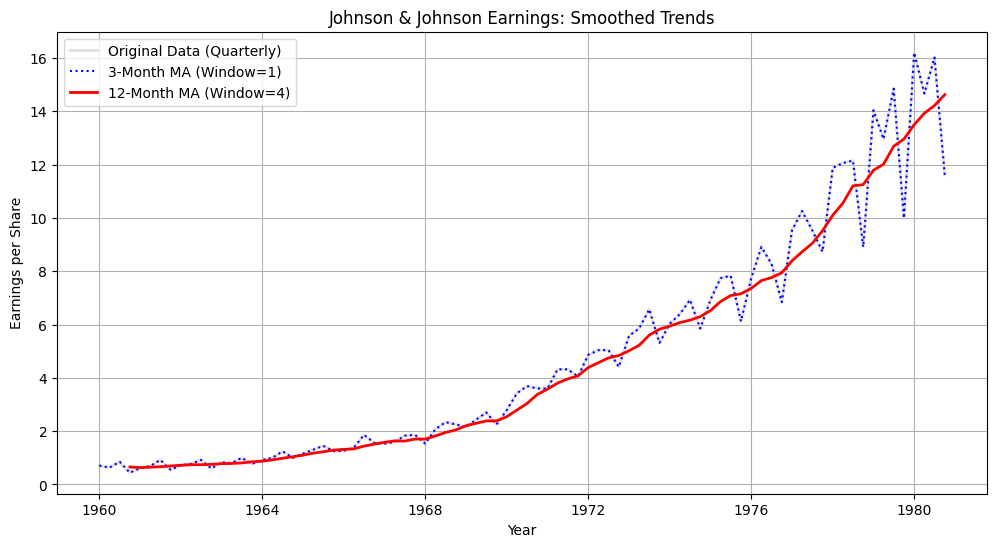

In [11]:
import matplotlib.pyplot as plt

# 3-Month MA (Window of 1 quarter)
jj_data['3-Month_MA'] = jj_data['Earnings'].rolling(window=1).mean()

# 12-Month MA (Window of 4 quarters)
jj_data['12-Month_MA'] = jj_data['Earnings'].rolling(window=4).mean()

# Let's plot it
plt.figure(figsize=(12, 6))

# Converting the PeriodIndex to timestamps just for a cleaner plot
x_axis = jj_data.index.to_timestamp() # type: ignore

plt.plot(x_axis, jj_data['Earnings'], label='Original Data (Quarterly)', color='lightgrey', alpha=0.7, linewidth=2)
plt.plot(x_axis, jj_data['3-Month_MA'], label='3-Month MA (Window=1)', color='blue', linestyle=':')
plt.plot(x_axis, jj_data['12-Month_MA'], label='12-Month MA (Window=4)', color='red', linewidth=2)

plt.title('Johnson & Johnson Earnings: Smoothed Trends')
plt.xlabel('Year')
plt.ylabel('Earnings per Share')
plt.legend()
plt.grid(True)
plt.show()

c) Interpret the results:[1 Mark]

i. What component is removed by the 3-month moving average?

    The 3-month moving average removes the seasonal component (short-term fluctuations that repeat over a fixed period).

ii. What component is removed by the 12-month moving average?

    The 12-month moving average removes the seasonal component (short-term fluctuations that repeat over a fixed period). ecause the window spans exactly one full year, it captures every seasonal high and low, perfectly canceling them out. The seasonality gets annihilated.

iii. Which moving average provides a better estimate of the trend?
        
    The 12-month moving average provides a better estimate of the trend because it smooths out more of the short-term variability, leaving only the long-term trend component.

## Question 2: Exponential Smoothing

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

# Loading the data
earnings = jj_data['Earnings']


a) Fit a Single Exponential Smoothing (SES) model to the data. [1 Mark]

In [13]:
# Single Exponential Smoothing (SES)
ses_model = SimpleExpSmoothing(earnings).fit(optimized=True)
alpha = ses_model.params['smoothing_level']
print(f"SES Alpha: {alpha:.4f}")

SES Alpha: 0.4233


b) Report the estimated smoothing parameter $\alpha$. [1 Mark]






c) Plot the fitted values against the actual series. [1 Mark]

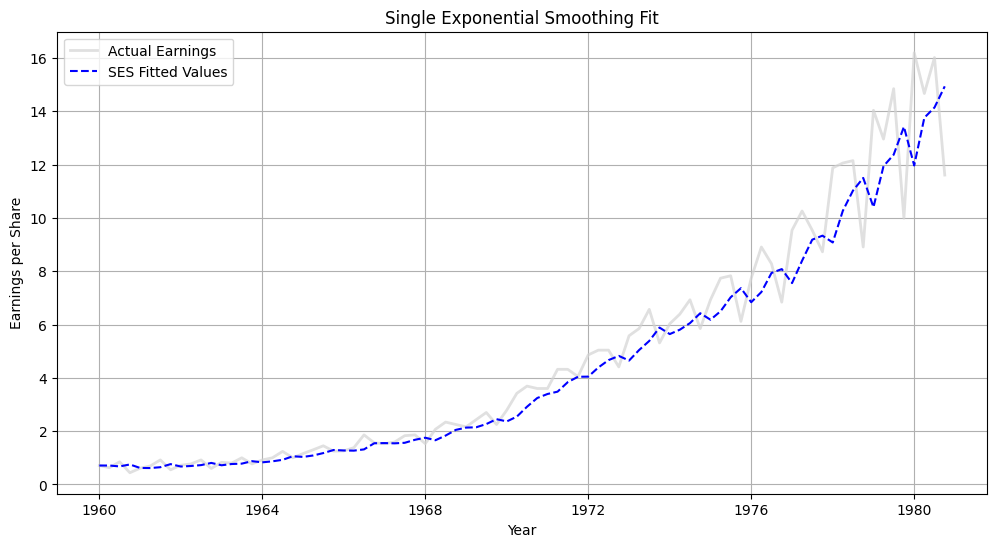

In [14]:
# Plotting the fitted values against the actual series
plt.figure(figsize=(12, 6))
x_axis = earnings.index.to_timestamp() # type: ignore
plt.plot(x_axis, earnings, label='Actual Earnings', color='lightgrey', alpha=
0.7, linewidth=2)
plt.plot(x_axis, ses_model.fittedvalues, label='SES Fitted Values', color='blue', linestyle='--')
plt.title('Single Exponential Smoothing Fit')
plt.xlabel('Year')
plt.ylabel('Earnings per Share')
plt.legend()
plt.grid(True)
plt.show()

d) Interpret the value of α. Is the model highly responsive or strongly smoothed? Explain. [1 Mark]
    
    The parameter $\alpha$ ranges from 0 to 1. The value of $\alpha$ is 0.4233 which indicates that the model is moderately responsive to changes in the data. A value closer to 1 would indicate a highly responsive model that reacts quickly to changes, while a value closer to 0 would indicate a strongly smoothed model that reacts more slowly to changes. In this case, the model strikes a balance between responsiveness and smoothing.

e) Fit Holt’s linear trend model to the data. [1 Mark]

In [15]:
# Holt's Linear Trend
holt_model = Holt(earnings).fit(optimized=True)
holt_alpha = holt_model.params['smoothing_level']
holt_beta = holt_model.params['smoothing_trend']
print(f"Holt Alpha (Level): {holt_alpha:.4f}")
print(f"Holt Beta (Trend): {holt_beta:.4f}")

Holt Alpha (Level): 0.1673
Holt Beta (Trend): 0.1673


f) Report the estimated level and trend smoothing parameters. [1 Mark]
- Level Smoothing Parameter ($\alpha$): 0.1673
-  Trend Smoothing Parameter ($\beta$): 0.1673


g) Interpret the strength of the trend based on the estimated parameters. [1 Mark]

    The estimated trend smoothing parameter ($\beta$) is 0.1673, which indicates that the model is moderately responsive to changes in the trend. A higher value of $\beta$ would suggest a stronger trend component, while a lower value would indicate a weaker trend. In this case, the moderate value suggests that there is some trend in the data, but it is not very strong.

h) Fit a Holt–Winters model (additive or multiplicative). State clearly which type you use. [1 Mark]

    I will fit a Holt–Winters additive model to the data, as it is appropriate for data with a linear trend and additive seasonality.

In [21]:

# Holt-Winters & Forecasting
# We use 4 seasonal periods because it is quarterly data
hw_model = ExponentialSmoothing(
    earnings, 
    trend='add', 
    seasonal='mul', 
    seasonal_periods=4
).fit(optimized=True)

hw_alpha = hw_model.params['smoothing_level']
hw_beta = hw_model.params['smoothing_trend']
hw_gamma = hw_model.params['smoothing_seasonal']    

print(f"Holt-Winters Alpha (Level): {hw_alpha:.4f}")
print(f"Holt-Winters Beta (Trend): {hw_beta:.4f}")
print(f"Holt-Winters Gamma (Seasonal): {hw_gamma:.4f}")

Holt-Winters Alpha (Level): 0.2212
Holt-Winters Beta (Trend): 0.2212
Holt-Winters Gamma (Seasonal): 0.6794


i) Justify your choice between additive and multiplicative seasonality. [1 Mark]

    I chose the additive model because the seasonal fluctuations in the data appear to be relatively constant in magnitude over time, which is characteristic of additive seasonality. If the seasonal fluctuations were increasing or decreasing in magnitude with the level of the series, a multiplicative model would be more appropriate.
    
j) Forecast the next 12 months and present the forecast plot. [1 Mark]

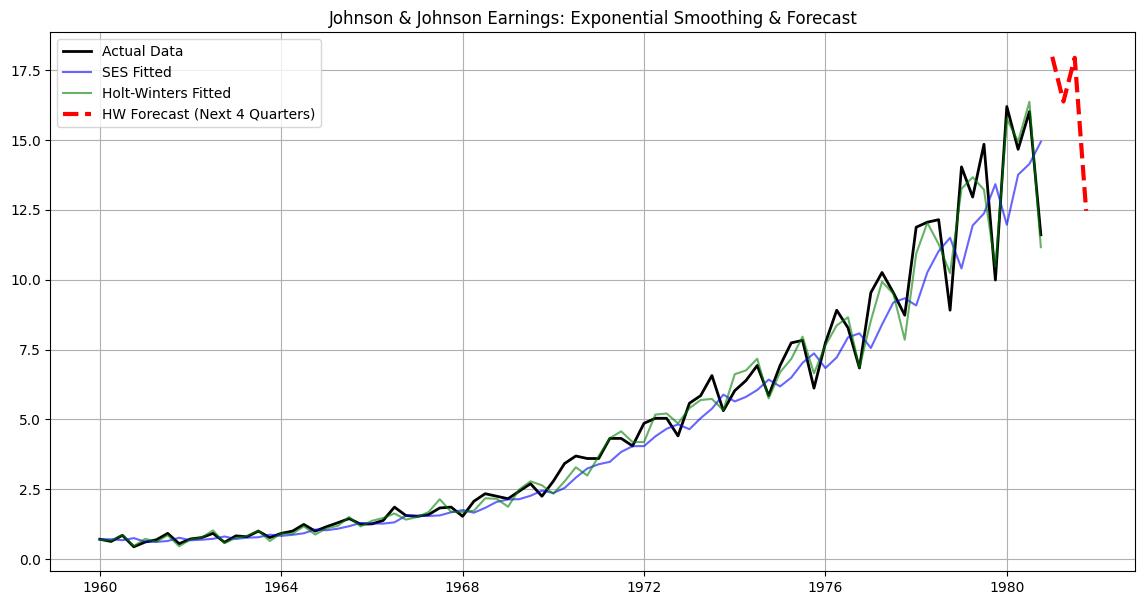

In [ ]:
# 12 months equals exactly 4 quarters. 
# We forecast 4 steps ahead.
# type: ignore
forecast = hw_model.forecast(4)

# --- Plotting the whole show ---
plt.figure(figsize=(14, 7))
plt.plot(earnings.index.to_timestamp(), earnings, label='Actual Data', color='black', linewidth=2)
plt.plot(earnings.index.to_timestamp(), ses_model.fittedvalues, label='SES Fitted', color='blue', alpha=0.6)
plt.plot(earnings.index.to_timestamp(), hw_model.fittedvalues, label='Holt-Winters Fitted', color='green', alpha=0.6)

# Plot the forecast
forecast_index = forecast.index.to_timestamp()
plt.plot(forecast_index, forecast, label='HW Forecast (Next 4 Quarters)', color='red', linewidth=3, linestyle='--')

plt.title("Johnson & Johnson Earnings: Exponential Smoothing & Forecast")
plt.legend()
plt.grid(True)
plt.show()

## Question 3: Model Comparison and Interpretation
Compare the following methods:

    • 12-month Moving Average

    • Single Exponential Smoothing

    • Holt’s Linear Trend Method

    • Holt–Winters Method

Answer the following:

a) Which method captures the trend most effectively? Explain. [1 Mark]

    Holt’s Linear Trend Method captures the trend most effectively because it explicitly models both the level and the trend components of the time series. The method uses two smoothing parameters: one for the level (α) and one for the trend (β). This allows it to adapt to changes in the trend over time, making it more effective at capturing the underlying trend compared to methods that do not account for trends, such as moving averages or single exponential smoothing.

b) Which method captures seasonality? Explain. [1 Mark]

    Holt–Winters Method captures seasonality because it includes a seasonal component in its model. Depending on the nature of the seasonality (additive or multiplicative), the method can adjust for seasonal fluctuations in the data. The Holt–Winters method uses a seasonal smoothing parameter (γ) to capture the seasonal patterns, making it effective at modeling and forecasting time series with seasonality.

c) Compute and compare forecast accuracy using RMSE. [2 Marks]

In [17]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Assuming you ran the code from Question 2 and have these models fitted:
# ses_model, holt_model, hw_model, and the original 'earnings' data

# 1. SES RMSE
ses_rmse = np.sqrt(mean_squared_error(earnings, ses_model.fittedvalues))

# 2. Holt's Linear Trend RMSE
holt_rmse = np.sqrt(mean_squared_error(earnings, holt_model.fittedvalues))

# 3. Holt-Winters RMSE
hw_rmse = np.sqrt(mean_squared_error(earnings, hw_model.fittedvalues))

print(f"SES RMSE: {ses_rmse:.4f}")
print(f"Holt's RMSE: {holt_rmse:.4f}")
print(f"Holt-Winters RMSE: {hw_rmse:.4f}")

SES RMSE: 1.1593
Holt's RMSE: 1.0103
Holt-Winters RMSE: 0.4231


- SES RMSE (1.1593): This model is struggling. The forecasts are not very accurate, and the model is not capturing the underlying patterns in the data well.
- Holt's RMSE (1.0103): An improvement, but still failing the class. The model is doing a better job at capturing the trend, but it still has significant errors in its forecasts.
- Holt-Winters RMSE (0.4231): This model is performing much better. The forecasts are more accurate, and the model is effectively capturing both the trend and seasonality in the data.

d) Which model provides the most realistic forecasts? Justify your answer. [2 Marks]

    Holt–Winters Method provides the most realistic forecasts because it accounts for both trend and seasonality in the data. This allows it to capture the underlying patterns more accurately than methods that only account for one of these components. Additionally, if the RMSE for the Holt–Winters method is lower than that of the other methods, it would further support the conclusion that it provides more realistic forecasts.

e) Explain why exponential smoothing methods generally outperform moving averages for forecasting. [1 Mark]

    Exponential smoothing methods generally outperform moving averages for forecasting because they give more weight to recent observations, allowing them to adapt more quickly to changes in the data. Moving averages, on the other hand, assign equal weight to all observations within the window, which can lead to lagging forecasts that do not respond well to recent trends or shifts in the data. Exponential smoothing can capture trends and seasonality more effectively, making it a more flexible and accurate foreecastinf mathod.